<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 3

### Details

**Topic:** Natural Language Processing

**Sub-topic:** Backpropagation

**Instructions:**

This problem challenges you to apply the full end-to-end workflow on a new dataset.
You will predict whether a bank customer is likely to default on a loan, a classic FinTech
problem.

Your Goal: Build, train, and evaluate an MLP to predict credit risk using the "German
Credit Data" dataset.

Your Task:
Load Data: Load the dataset from the following URL into a pandas DataFrame. The
target column is named Creditability. URL: https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data


Note: This file has no header. You will need to manually assign column names. A list of
names is provided in the solution hint.

Preprocess the Data:

The data is space-separated. Many columns are categorical (e.g., 'A11', 'A32'). Use one-hot encoding
(pd.get_dummies) to convert them into numerical format.
- Standardize all numerical features using StandardScaler.
- Split the data into an 80% training set and a 20% testing set.
- Create DataLoaders: Convert your processed data into PyTorch Tensors and create
DataLoaders for both the training and test sets.
- Build an MLP: Define a new nn.Module class for your MLP. It should have at least two
hidden layers. You can choose the number of neurons in each layer.
Train the Model: Write a training loop. Use nn.BCELoss and the Adam optimizer. Train
for at least 50 epochs.
- Evaluate the Model: After training, calculate and print the final accuracy on the test set.


Hint:
- Column Names: You can use this list of column names: ["Status of existing checking
account", "Duration in month", "Credit history", "Purpose", "Credit amount", "Savings
account/bonds", "Present employment since", "Installment rate in percentage of
disposable income", "Personal status and sex", "Other debtors / guarantors", "Present
residence since", "Property", "Age in years", "Other installment plans", "Housing",
"Number of existing credits at this bank", "Job", "Number of people being liable to
provide maintenance for", "Telephone", "foreign worker", "Creditability"].
- Preprocessing: Remember to apply StandardScaler after you split the data to avoid data
leakage from the test set into the training set. Fit the scaler on the training data and use
it to transform both train and test data.
- Target Column: The original target (Creditability) has values 1 (Good) and 2 (Bad). You
should map this to 0 (Bad) and 1 (Good) to be compatible with nn.BCELoss. y =
y.replace({1: 1, 2: 0}).

**What I found interesting:**

-  Code is simultaneously constructing every operation in memory at each forward pass
- Method used (.backward()) is interesting from a mathematical/intuitive perspective: chain-rule applied backwards to every node in the graph, enabled through reverse-mode differentiation computing all partial derivatives in ~one backward pass, regardless of how many parameters exist
- Learning stops due to anishing gradients trhough saturated functions, which happens naturally

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"Device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.10.0+cpu
Device available: cpu


### Load data


In [2]:

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

COLUMN_NAMES = [
    "Status of existing checking account",
    "Duration in month",
    "Credit history",
    "Purpose",
    "Credit amount",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Age in years",
    "Other installment plans",
    "Housing",
    "Number of existing credits at this bank",
    "Job",
    "Number of people being liable to provide maintenance for",
    "Telephone",
    "foreign worker",
    "Creditability"
]

df = pd.read_csv(URL, sep=' ', header=None, names=COLUMN_NAMES)

print(f"Dataset shape : {df.shape}")
print(f"\nTarget distribution (raw):")
print(df['Creditability'].value_counts())
df.head()

Dataset shape : (1000, 21)

Target distribution (raw):
Creditability
1    700
2    300
Name: count, dtype: int64


,Status of existing checking account,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker,Creditability
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### Preprocessing the data

In [3]:
# ── 2a. Remap target: 1 (Good) → 1, 2 (Bad) → 0 ──────────────────────────
df['Creditability'] = df['Creditability'].map({1: 1, 2: 0})

print("Remapped target distribution:")
print(df['Creditability'].value_counts())
print(f"  0 = Bad credit risk, 1 = Good credit risk")

Remapped target distribution:
Creditability
1    700
0    300
Name: count, dtype: int64
  0 = Bad credit risk, 1 = Good credit risk


In [4]:
# ── 2b. Identify categorical vs numeric columns ────────────────────────────
# Categorical columns hold string codes (dtype=object)
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols + ['Creditability']]

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns    ({len(num_cols)}): {num_cols}")

# ── 2c. One-hot encode categorical columns ─────────────────────────────────
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")

Categorical columns (13): ['Status of existing checking account', 'Credit history', 'Purpose', 'Savings account/bonds', 'Present employment since', 'Personal status and sex', 'Other debtors / guarantors', 'Property', 'Other installment plans', 'Housing', 'Job', 'Telephone', 'foreign worker']
Numeric columns    (7): ['Duration in month', 'Credit amount', 'Installment rate in percentage of disposable income', 'Present residence since', 'Age in years', 'Number of existing credits at this bank', 'Number of people being liable to provide maintenance for']

Shape after one-hot encoding: (1000, 49)


In [5]:
# ── 2d. Separate features and target, then split 80/20 ────────────────────
X = df_encoded.drop(columns=['Creditability']).values.astype(np.float32)
y = df_encoded['Creditability'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Feature count  : {X_train.shape[1]}")

Training set   : 800 samples
Test set       : 200 samples
Feature count  : 48


In [6]:
# ── 2e. Standardise — fit ONLY on train, transform both ───────────────────
# This prevents test-set information leaking into the scaler (data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test  = scaler.transform(X_test)        # transform only on test

print("Scaling complete.")
print(f"Train feature mean (should be ≈ 0): {X_train.mean():.4f}")
print(f"Train feature std  (should be ≈ 1): {X_train.std():.4f}")

Scaling complete.
Train feature mean (should be ≈ 0): 0.0000
Train feature std  (should be ≈ 1): 1.0000


### Create PyTorch Dataloaders

In [7]:
BATCH_SIZE = 32

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # shape (N,1) for BCELoss
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

# Wrap in TensorDataset
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")

# Inspect one batch
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch — X: {sample_X.shape}, y: {sample_y.shape}")

Training batches : 25
Test batches     : 7

Sample batch — X: torch.Size([32, 48]), y: torch.Size([32, 1])


### Define MLP Architecture

In [8]:
class CreditMLP(nn.Module):
    """Multilayer Perceptron for binary credit risk classification."""

    def __init__(self, input_dim):
        super(CreditMLP, self).__init__()

        self.network = nn.Sequential(
            # Hidden layer 1
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Hidden layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Hidden layer 3
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output layer — sigmoid squashes to [0,1] for BCELoss
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


INPUT_DIM = X_train_t.shape[1]
model = CreditMLP(input_dim=INPUT_DIM).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

CreditMLP(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 16,641


### Train model

In [9]:
EPOCHS = 100
LEARNING_RATE = 1e-3

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Storage for learning curves
train_losses = []
train_accs   = []
test_accs    = []

for epoch in range(1, EPOCHS + 1):

    # ── Training phase ───────────────────────────────────────────────────
    model.train()
    epoch_loss  = 0.0
    correct     = 0
    total       = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        # Forward pass
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        predicted   = (y_pred >= 0.5).float()
        correct    += (predicted == y_batch).sum().item()
        total      += y_batch.size(0)

    avg_loss   = epoch_loss / total
    train_acc  = correct / total

    # ── Validation phase (no gradient computation) ───────────────────────
    model.eval()
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            y_pred     = model(X_batch)
            predicted  = (y_pred >= 0.5).float()
            val_correct += (predicted == y_batch).sum().item()
            val_total   += y_batch.size(0)

    val_acc = val_correct / val_total

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"Loss: {avg_loss:.4f}  "
              f"Train Acc: {train_acc:.4f}  "
              f"Test Acc: {val_acc:.4f}")

print("\nTraining complete.")

Epoch   1/100  Loss: 0.6420  Train Acc: 0.6963  Test Acc: 0.7000
Epoch  10/100  Loss: 0.3671  Train Acc: 0.8363  Test Acc: 0.7050
Epoch  20/100  Loss: 0.2180  Train Acc: 0.9150  Test Acc: 0.7300
Epoch  30/100  Loss: 0.1355  Train Acc: 0.9537  Test Acc: 0.7000
Epoch  40/100  Loss: 0.1079  Train Acc: 0.9600  Test Acc: 0.7350
Epoch  50/100  Loss: 0.0763  Train Acc: 0.9712  Test Acc: 0.7250
Epoch  60/100  Loss: 0.0688  Train Acc: 0.9750  Test Acc: 0.7200
Epoch  70/100  Loss: 0.0500  Train Acc: 0.9788  Test Acc: 0.7250
Epoch  80/100  Loss: 0.0567  Train Acc: 0.9838  Test Acc: 0.7350
Epoch  90/100  Loss: 0.0461  Train Acc: 0.9850  Test Acc: 0.7150
Epoch 100/100  Loss: 0.0410  Train Acc: 0.9850  Test Acc: 0.7300

Training complete.


### Model Evaluation

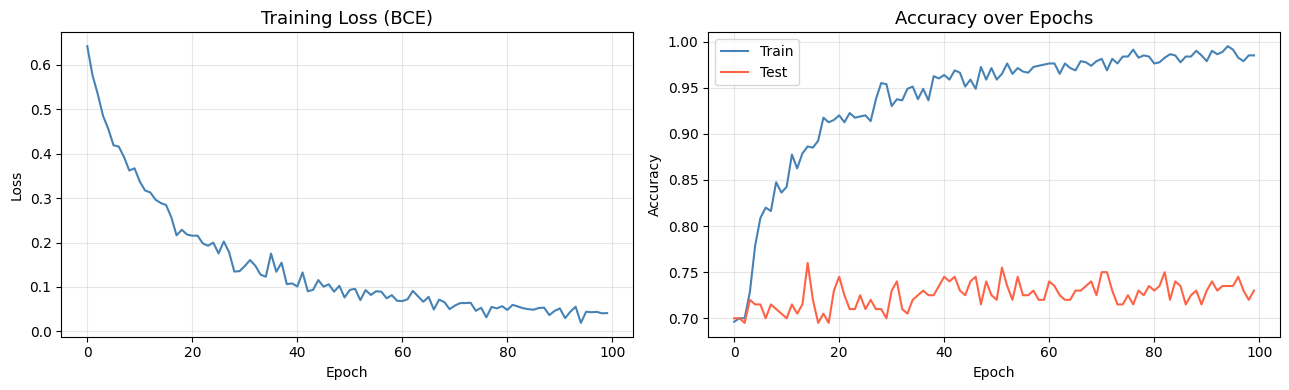

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
axes[0].plot(train_losses, color='steelblue', linewidth=1.5)
axes[0].set_title('Training Loss (BCE)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(train_accs, label='Train', color='steelblue', linewidth=1.5)
axes[1].plot(test_accs,  label='Test',  color='tomato',    linewidth=1.5)
axes[1].set_title('Accuracy over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ── Final evaluation on the full test set ─────────────────────────────────
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch  = X_batch.to(DEVICE)
        y_pred   = model(X_batch)
        predicted = (y_pred >= 0.5).float().cpu().numpy()
        all_preds.extend(predicted.flatten())
        all_labels.extend(y_batch.numpy().flatten())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

final_accuracy = (all_preds == all_labels).mean()
print(f"Final Test Accuracy : {final_accuracy:.4f}  ({final_accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Bad (0)', 'Good (1)']))

Final Test Accuracy : 0.7300  (73.00%)

Classification Report:
              precision    recall  f1-score   support

     Bad (0)       0.55      0.55      0.55        60
    Good (1)       0.81      0.81      0.81       140

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.73      0.73       200



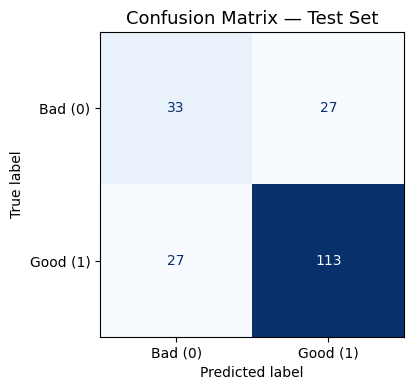

In [12]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad (0)', 'Good (1)'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()